In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

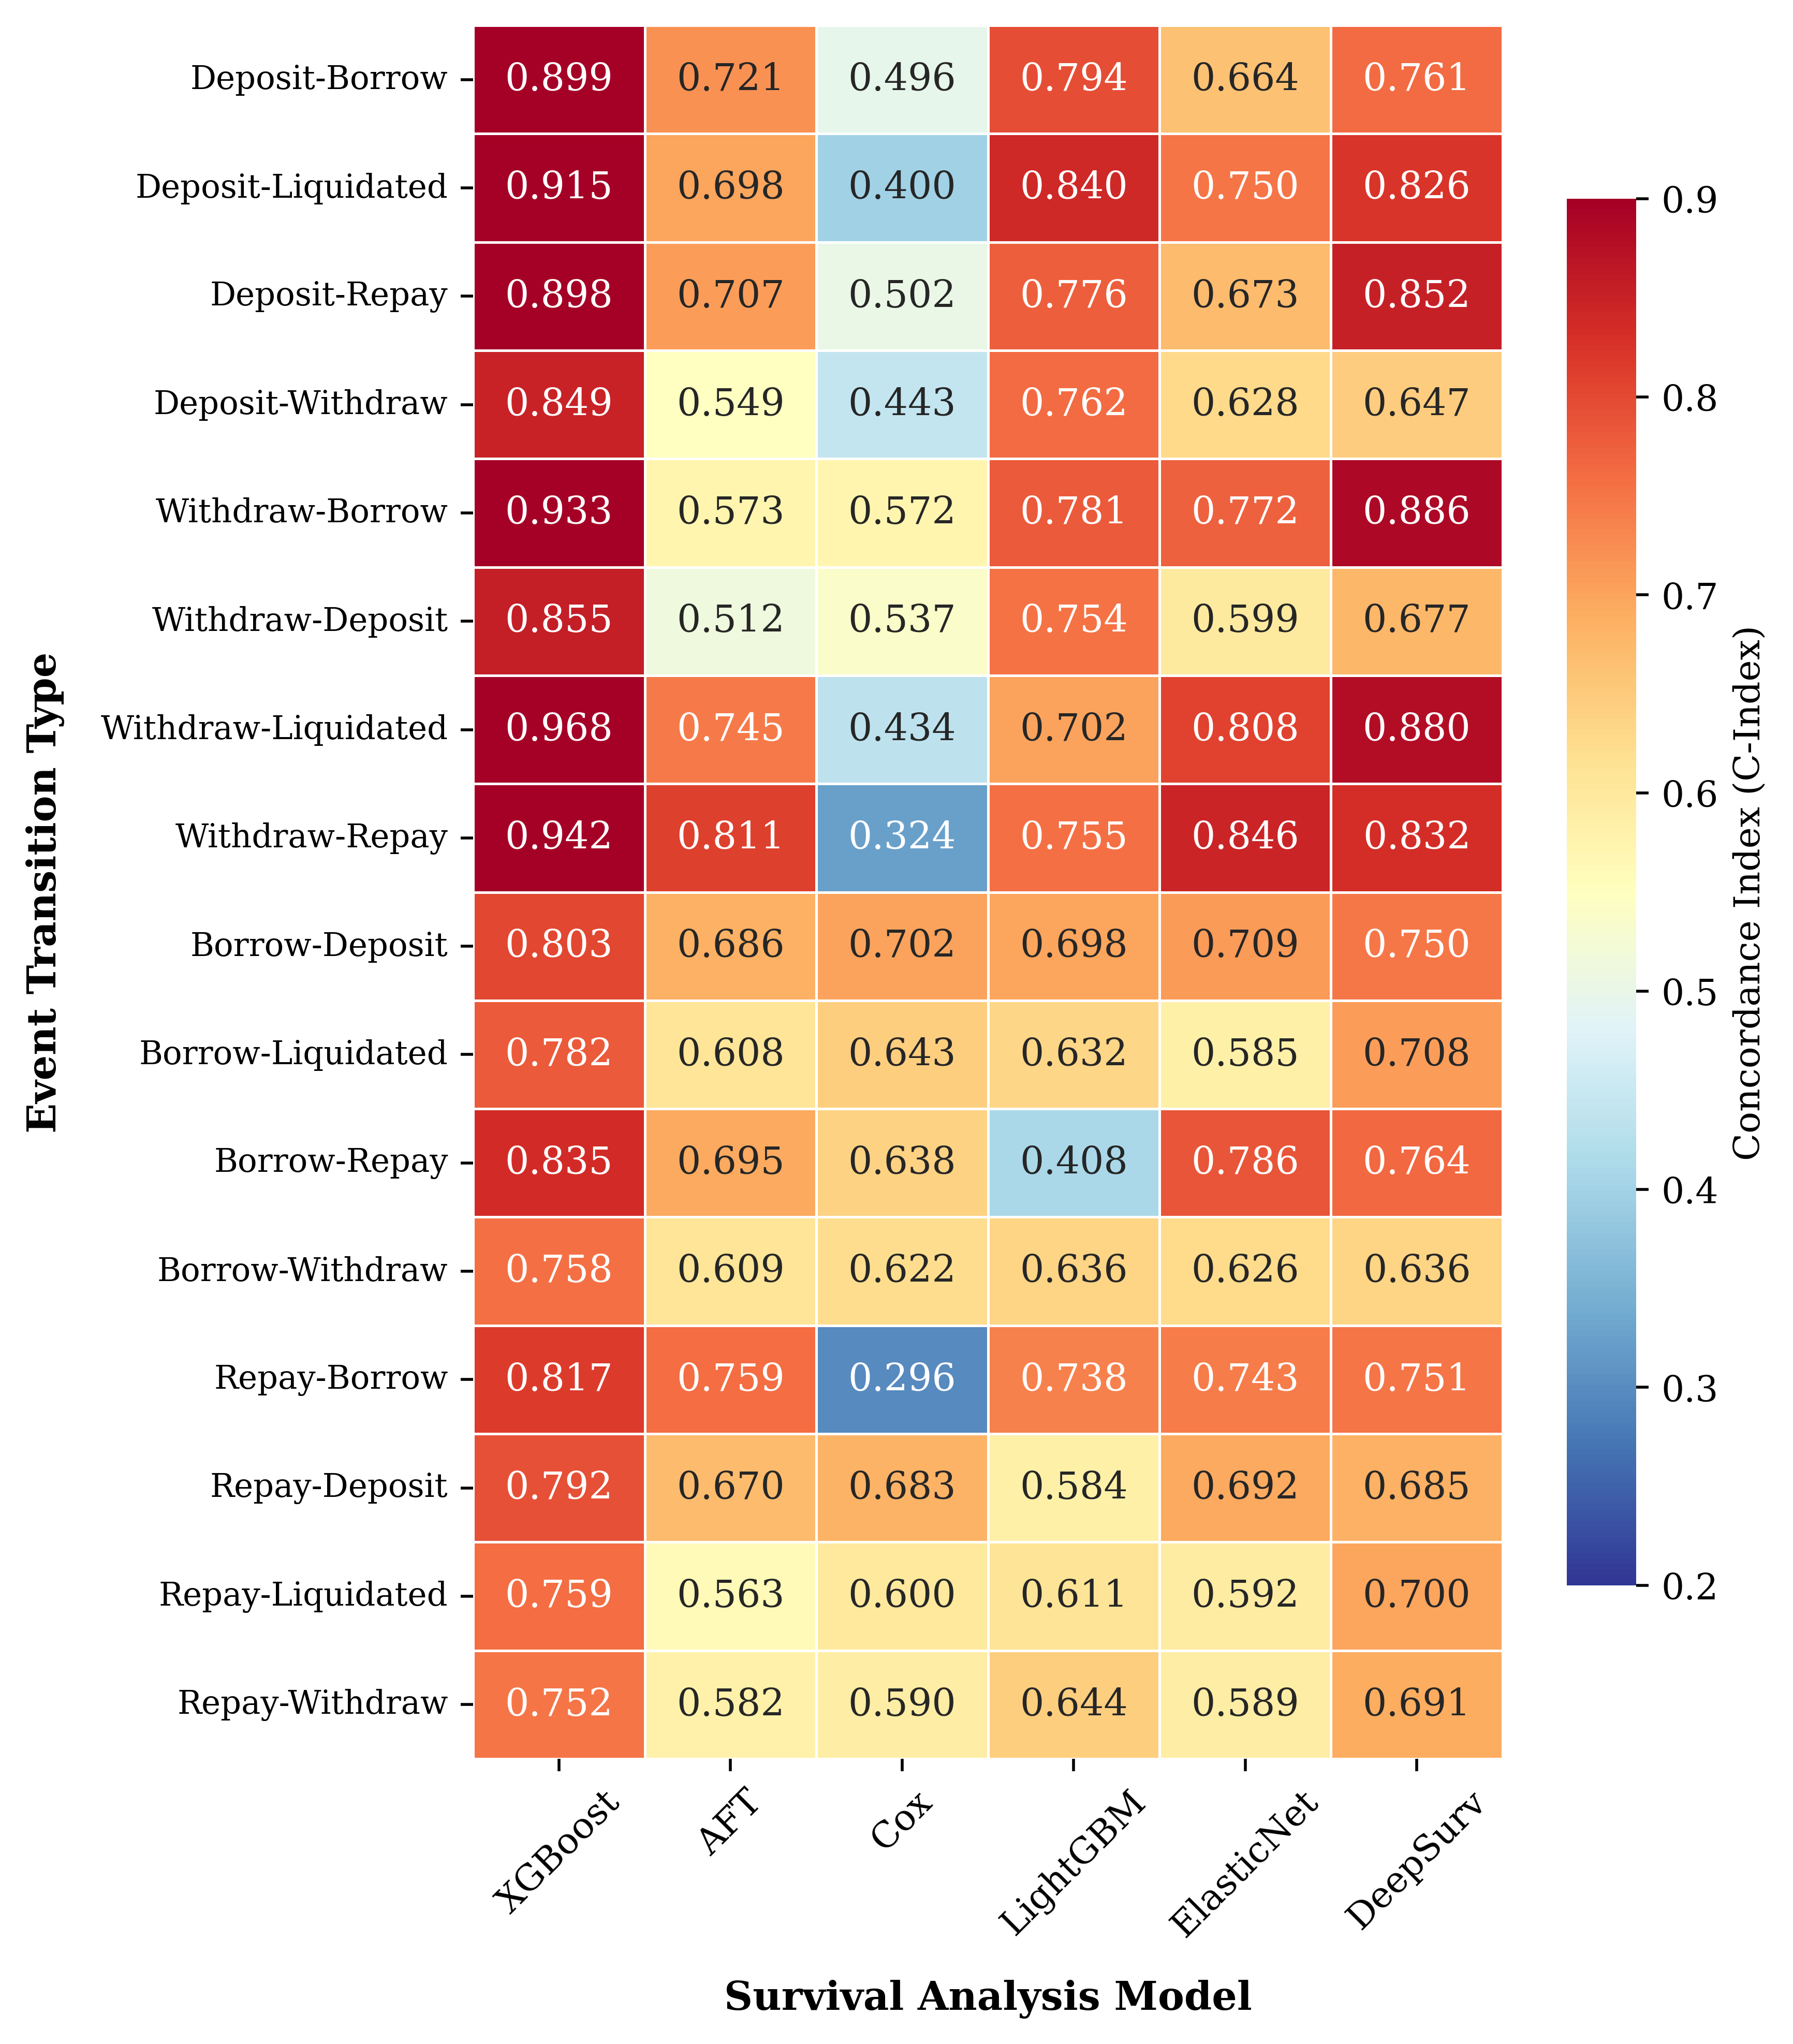

In [2]:
labels = [
        "Deposit-Borrow", "Deposit-Liquidated", "Deposit-Repay", "Deposit-Withdraw",
        "Withdraw-Borrow", "Withdraw-Deposit", "Withdraw-Liquidated", "Withdraw-Repay",
        "Borrow-Deposit", "Borrow-Liquidated", "Borrow-Repay", "Borrow-Withdraw",
        "Repay-Borrow", "Repay-Deposit", "Repay-Liquidated", "Repay-Withdraw"
]

data = {
    'XGBoost': [0.8991, 0.9148, 0.8981, 0.8487, 
                0.9326, 0.8546, 0.9679, 0.9415, 
                0.8034, 0.7823, 0.8346, 0.7576, 
                0.8167, 0.7924, 0.7592, 0.7520],

    'AFT':     [0.7208, 0.6981, 0.7069, 0.5495, 
                0.5726, 0.5120, 0.7450, 0.8108, 
                0.6858, 0.6083, 0.6947, 0.6088, 
                0.7586, 0.6704, 0.5629, 0.5815],

    'Cox':     [0.4961, 0.3995, 0.5016, 0.4427, 
                0.5722, 0.5375, 0.4338, 0.3240, 
                0.7023, 0.6433, 0.6381, 0.6221, 
                0.2960, 0.6831, 0.6000, 0.5903],

    'LightGBM': [0.7945, 0.8402, 0.7763, 0.7618, 
                0.7812, 0.7536, 0.7018, 0.7551, 
                0.6977, 0.6321, 0.4084, 0.6356, 
                0.7382, 0.5843, 0.6114, 0.6441],

    'ElasticNet': [0.6639, 0.7504, 0.6730, 0.6280, 
                    0.7718, 0.5986, 0.8083, 0.8457, 
                    0.7090, 00.5848, 0.7862, 0.6257, 
                    0.7432, 0.6923, 0.5921, 0.5886],

    'DeepSurv':[0.7610, 0.8257, 0.8516, 0.6468, 
                0.8865, 0.6774, 0.8804, 0.8323, 
                0.7496, 0.7083, 0.7643, 0.6358, 
                0.7509, 0.6854, 0.7003, 0.6911],
}


df = pd.DataFrame(data, index=labels)

# Set publication-quality parameters (using default serif font available on system)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

# Create figure with specific size for papers
fig, ax = plt.subplots(figsize=(7, 8), dpi=500)

# Create heatmap with better formatting
sns.heatmap(
    df,
    annot=True,
    fmt='.3f',
    cmap='RdYlBu_r',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={
        'label': 'Concordance Index (C-Index)',
        'shrink': 0.8,
        'aspect': 20
    },
    vmin=0.2,
    vmax=0.9,
    square=False,
    ax=ax,
    annot_kws={'fontsize': 10.5,}  
)

# Axis labels
ax.set_xlabel('Survival Analysis Model', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Event Transition Type', fontsize=11, fontweight='bold', labelpad=10)

# Rotate and align labels
plt.xticks(rotation=45, ha='center', fontsize=10)
plt.yticks(rotation=0, fontsize=9)

# Remove spines for cleaner look
for spine in ax.spines.values():
    spine.set_visible(False)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save as high-resolution image for paper
plt.savefig('heatmap.png', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

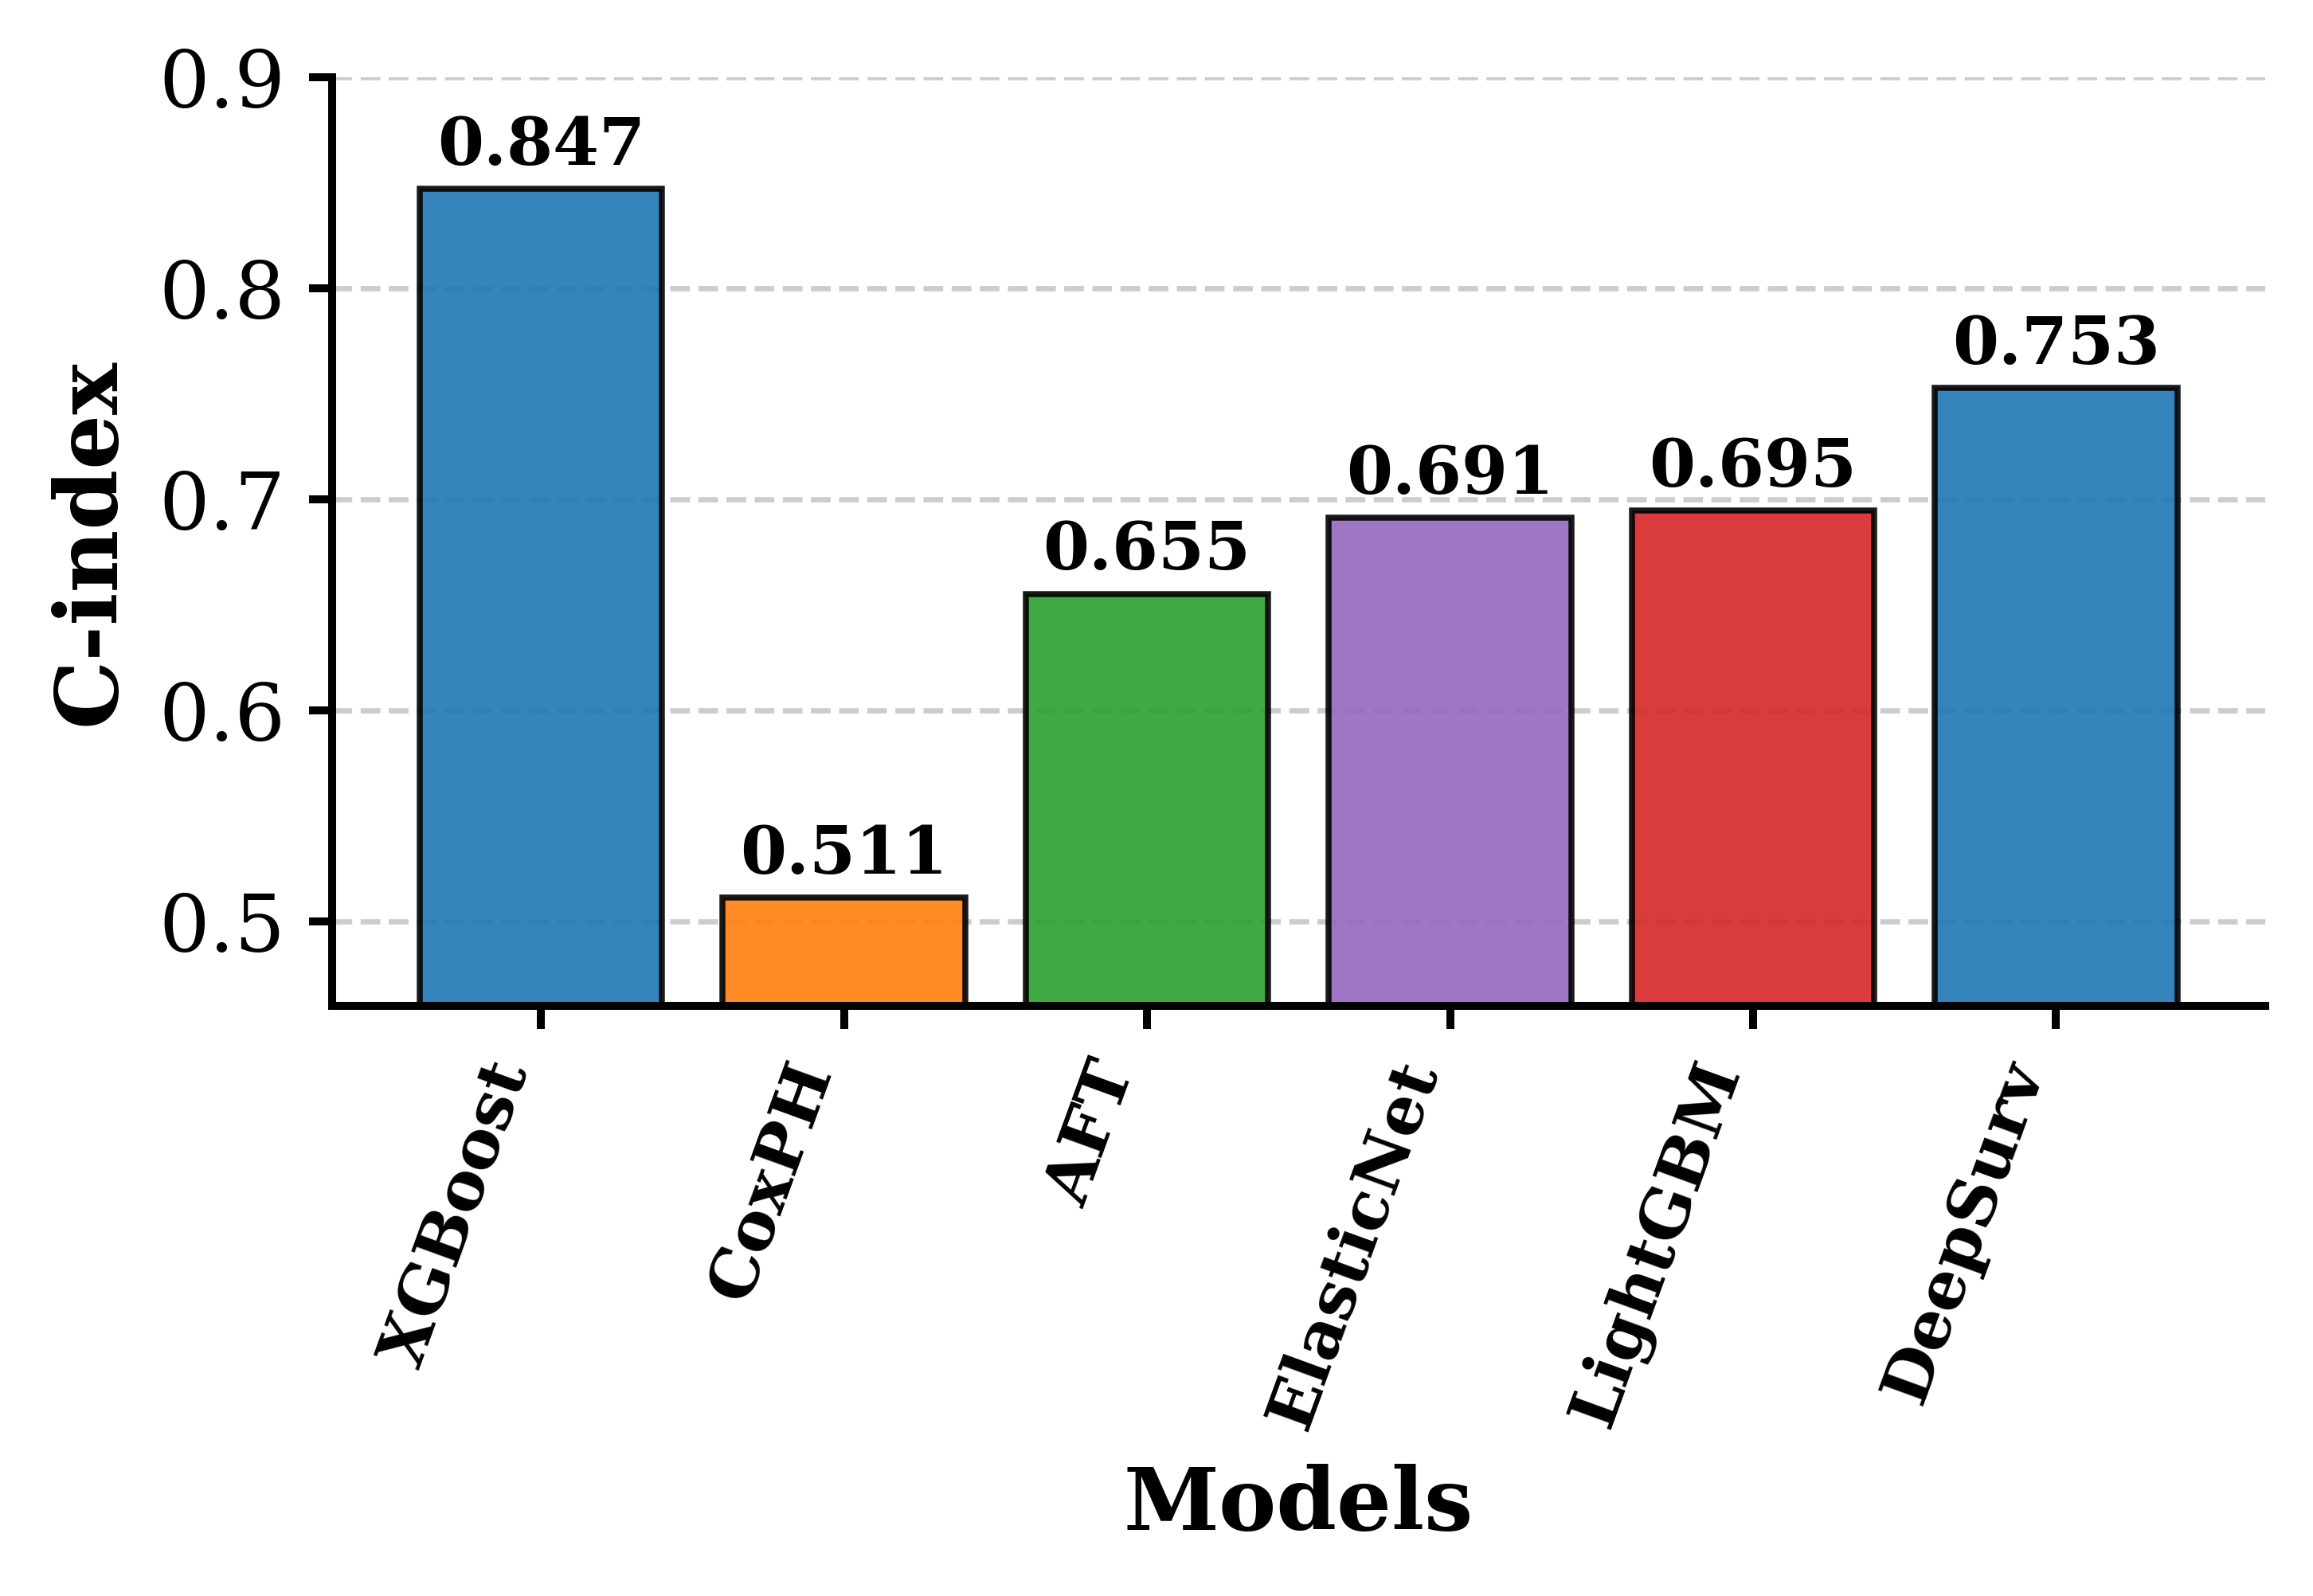

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'text.usetex': False,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'grid.linewidth': 0.8
})

# Model names (x-axis)
models = ['XGBoost', 'CoxPH', 'AFT', 'ElasticNet', 'LightGBM', 'DeepSurv']
cindex_values = [0.8472, 0.5114, 0.6554, 0.6914, 0.6948, 0.7530]  # Example C-index values

# Create figure
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=600)

# Colors for each model (consistent with previous palette)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728']

# Bar chart
x = np.arange(len(models))
bars = ax.bar(x, cindex_values, color=colors, edgecolor='black', linewidth=0.9, alpha=0.9)

# Add value labels on top of bars
for i, val in enumerate(cindex_values):
    ax.text(i, val + 0.005, f'{val:.3f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='black')

# Axis labels and title
ax.set_xlabel('Models', fontsize=13, fontweight='bold')
ax.set_ylabel('C-index', fontsize=13, fontweight='bold')

# X ticks
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10, fontweight='bold', rotation=70, ha='right')

# Y-axis limits for spacing
ax.set_ylim(0.46, 0.90)

# Gridlines for readability
ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.4, color='gray')
ax.set_axisbelow(True)

# Remove top/right spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Adjust bottom/left spine aesthetics
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(1.2)
    ax.spines[spine].set_color('black')

# Tight layout and save
plt.tight_layout()
plt.savefig('cindex_bar.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
